# Decision Tree (Classification) with scikit-learn

This notebook uses a real dataset (Iris) to show: model training, tuning,
and a tree visualization.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score

np.set_printoptions(precision=3, suppress=True)


## 1) Load a real dataset
We use the classic Iris dataset with 3 classes and 4 features.


In [2]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
class_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


## 2) Base model (default parameters)
This is a baseline accuracy to compare against tuning.


In [3]:
base_model = DecisionTreeClassifier(random_state=42)
base_model.fit(X_train, y_train)

train_pred = base_model.predict(X_train)
test_pred = base_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)

print('Base train accuracy:', train_acc)
print('Base test accuracy:', test_acc)


Base train accuracy: 1.0
Base test accuracy: 0.9333333333333333


## 3) Hyperparameter tuning
We tune `max_depth` and `min_samples_split`.
If a parameter **does not change** accuracy, the constraint may not be active
for this dataset (e.g., the tree is already shallow).


In [ ]:
results = []

for max_depth in [1, 2, 3, 4, None]:
    for min_samples_split in [2, 5, 10]:
        model = DecisionTreeClassifier(
            random_state=42,
            max_depth=max_depth,
            min_samples_split=min_samples_split,
        )
        model.fit(X_train, y_train)
        train_acc = accuracy_score(y_train, model.predict(X_train))
        test_acc = accuracy_score(y_test, model.predict(X_test))
        results.append((max_depth, min_samples_split, train_acc, test_acc))

for max_depth, min_samples_split, train_acc, test_acc in results:
    print(
        f'max_depth={max_depth}, min_samples_split={min_samples_split} -> '
        f'train={train_acc:.3f}, test={test_acc:.3f}'
    )


# task 1: Use GridSearchCV to find the best hyperparameters for the DecisionTreeClassifier on the Iris dataset.

max_depth=1, min_samples_split=2 -> train=0.667, test=0.667
max_depth=1, min_samples_split=5 -> train=0.667, test=0.667
max_depth=1, min_samples_split=10 -> train=0.667, test=0.667
max_depth=2, min_samples_split=2 -> train=0.967, test=0.933
max_depth=2, min_samples_split=5 -> train=0.967, test=0.933
max_depth=2, min_samples_split=10 -> train=0.967, test=0.933
max_depth=3, min_samples_split=2 -> train=0.983, test=0.967
max_depth=3, min_samples_split=5 -> train=0.983, test=0.967
max_depth=3, min_samples_split=10 -> train=0.983, test=0.967
max_depth=4, min_samples_split=2 -> train=0.992, test=0.933
max_depth=4, min_samples_split=5 -> train=0.983, test=0.967
max_depth=4, min_samples_split=10 -> train=0.983, test=0.967
max_depth=None, min_samples_split=2 -> train=1.000, test=0.933
max_depth=None, min_samples_split=5 -> train=0.983, test=0.967
max_depth=None, min_samples_split=10 -> train=0.983, test=0.967


## 4) Visualize the tree
We plot a small tree to inspect split rules.


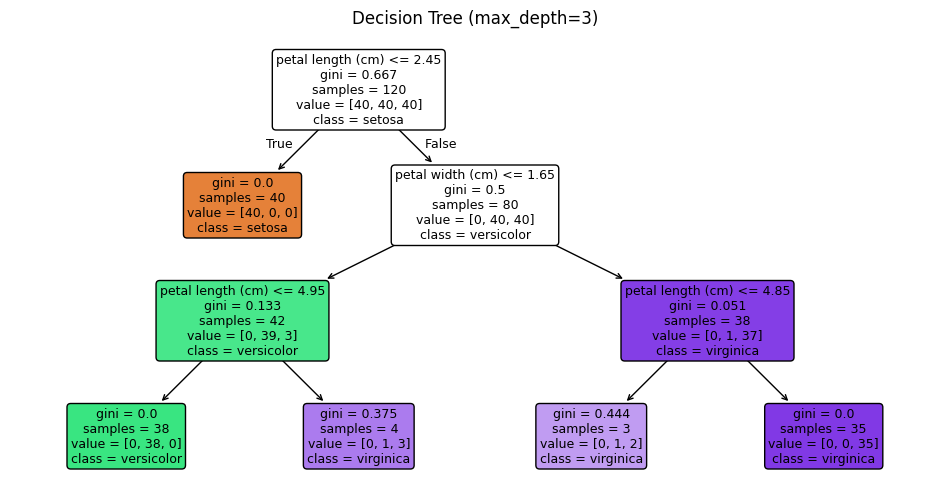

In [10]:
viz_model = DecisionTreeClassifier(random_state=42, max_depth=3)
viz_model.fit(X_train, y_train)

plt.figure(figsize=(12, 6))
plot_tree(
    viz_model,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
)
plt.title('Decision Tree (max_depth=3)')
plt.show()


In [ ]:
#Task 2  train DT_ R with categorical variable and plot the tree ( Observe how categorical variables are handled)
import numpy as np
import pandas as pd
data ={
    'product_cat': np.random.choice(['A', 'B', 'C'], size=5000),
    'price': np.random.rand(5000) * 100,
    'rating': np.random.rand(5000) * 5,
    'Target': np.random.choice([True, False], size=5000)
}

df = pd.DataFrame(data)
df.head()

,product_cat,price,rating,Target
0,A,21.127145,0.331454,True
1,A,53.202469,1.557456,True
2,B,47.362041,1.931546,False
3,B,61.116921,2.877687,False
4,B,49.423562,0.052979,False
